# I.7 Autovalores e Autovetores

Ao aplicarmos uma transformação linear representada por uma matriz $A$ sobre um vetor $v$, o resultado $Av$ é, em geral, um vetor com direção e módulo diferentes dos de $v$. No entanto, para algumas direções especiais, a transformação apenas *estica*, *encolhe* ou *inverte o sentido* do vetor, sem alterar sua direção. Essas direções especiais são chamadas de **autovetores** (*eigenvectors*) e o fator de escala associado a cada uma delas é chamado de **autovalor** (*eigenvalue*).

Autovalores e autovetores estão entre os conceitos mais importantes da Álgebra Linear, com aplicações em praticamente todas as áreas da ciência e da engenharia: análise de estabilidade de sistemas dinâmicos, vibrações mecânicas, processamento de imagens, redução de dimensionalidade de dados (PCA), motores de busca (PageRank) e também em Métodos Numéricos. Por exemplo, vimos em [I.6](I.6_metodos_iterativos_para_sistemas_lineares.ipynb) que a convergência dos métodos iterativos de Jacobi-Richardson e Gauss-Seidel depende diretamente dos autovalores da matriz de iteração $H$.

## Definição

Seja $A$ uma matriz quadrada de ordem $n$. Dizemos que um escalar $\lambda$ (real ou complexo) é um **autovalor** de $A$ se existir um vetor **não nulo** $v \in \mathbb{R}^n$ tal que

$$ A v = \lambda v $$

Nesse caso, $v$ é chamado de **autovetor** de $A$ associado ao autovalor $\lambda$.

Geometricamente, isso significa que a transformação linear definida por $A$ leva o vetor $v$ em um múltiplo escalar de si mesmo, ou seja, não altera a *direção* de $v$ (podendo alterar seu sentido e/ou o seu módulo).

## Polinômio característico

A equação $Av = \lambda v$ pode ser reescrita como

$$ Av - \lambda v = 0 \quad \Longrightarrow \quad (A - \lambda I) v = 0$$

em que $I$ é a matriz identidade de ordem $n$. Essa é a equação de um sistema linear homogêneo com incógnita $v$. Como estamos interessados apenas em soluções **não nulas** ($v \neq 0$), o sistema deve ser **indeterminado**, o que ocorre se, e somente se, a matriz dos coeficientes $(A-\lambda I)$ não for invertível, ou seja,

$$ \det(A - \lambda I) = 0 $$

Essa equação é chamada de **equação característica** de $A$, e $p(\lambda) = \det(A-\lambda I)$ é o **polinômio característico** de $A$, um polinômio de grau $n$ em $\lambda$. As raízes de $p(\lambda)$ são exatamente os autovalores de $A$.

Uma vez encontrado um autovalor $\lambda$, os autovetores associados a ele são obtidos resolvendo o sistema linear homogêneo $(A-\lambda I)v=0$. O conjunto de todas as soluções desse sistema (incluindo o vetor nulo) é um subespaço vetorial chamado **autoespaço** associado a $\lambda$.

**Exemplo 1:** Vamos determinar os autovalores e autovetores da matriz

$$
A = \begin{bmatrix}
4 & 0 & 1 \\
-2 & 1 & 0 \\
-2 & 0 & 1
\end{bmatrix}
$$

Para isso, vamos usar o `sympy` para montar e resolver a equação característica $\det(\lambda I - A)=0$ (equivalente a $\det(A-\lambda I)=0$, a menos de sinal, o que não altera as raízes).

In [1]:
import sympy as sp
sp.init_printing(use_unicode=True)

In [2]:
lamb, x1, x2, x3 = sp.symbols('lambda x_1 x_2 x_3')
A = sp.Matrix([[4,0,1],[-2,1,0],[-2,0,1]])
I = sp.eye(3)
eq = sp.Eq((lamb*sp.eye(3)-A).det(), 0)
display(eq)

A expressão acima é o polinômio característico de $A$ igualado a zero. Vamos resolver essa equação para obter os autovalores.

In [3]:
r = sp.solve(eq)
r

Encontramos três autovalores reais. Para cada autovalor $\lambda_i$, os autovetores associados são as soluções não nulas do sistema homogêneo $(A-\lambda_i I)v = 0$.

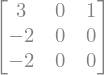

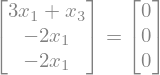

In [4]:
display((A-r[0]*I))
sh = sp.Eq((A-r[0]*I)*sp.Matrix([x1,x2,x3]), sp.Matrix([0,0,0]))
display(sh)
sp.solve(sh)

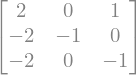

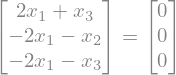

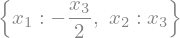

In [5]:
display((A-r[1]*I))
sh = sp.Eq((A-r[1]*I)*sp.Matrix([x1,x2,x3]), sp.Matrix([0,0,0]))
display(sh)
sp.solve(sh)

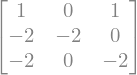

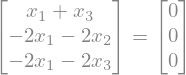

In [6]:
display((A-r[2]*I))
sh = sp.Eq((A-r[2]*I)*sp.Matrix([x1,x2,x3]), sp.Matrix([0,0,0]))
display(sh)
sp.solve(sh)

Observe que, em cada caso, a solução é dada em função de uma variável livre: isso significa que o autoespaço associado a cada autovalor tem dimensão 1, ou seja, é gerado por um único autovetor (a menos de múltiplo escalar).

Como esse tipo de cálculo é muito comum, o `sympy` já disponibiliza métodos prontos para matrizes, que fazem exatamente o que fizemos manualmente acima.

In [7]:
# autovalores (e suas multiplicidades algébricas)
A.eigenvals()

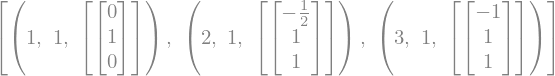

In [8]:
# autovalores, multiplicidades e autovetores associados
A.eigenvects()

## Multiplicidade algébrica e multiplicidade geométrica

Quando o polinômio característico tem uma raiz repetida, dizemos que o autovalor correspondente tem **multiplicidade algébrica** maior que 1 (igual ao número de vezes que a raiz se repete). Já a **multiplicidade geométrica** de um autovalor é a dimensão do seu autoespaço, ou seja, o número máximo de autovetores linearmente independentes associados a ele.

Sempre vale que

$$ 1 \leq \text{multiplicidade geométrica} \leq \text{multiplicidade algébrica} $$

No Exemplo 1, todos os autovalores são distintos (multiplicidade algébrica 1), logo a multiplicidade geométrica de cada um também é 1, como confirmamos acima.

## Interpretação geométrica

A definição $Av=\lambda v$ nos diz que, para um autovetor $v$, o vetor transformado $Av$ é **paralelo** a $v$ (mesma direção, podendo mudar o sentido se $\lambda<0$ e o comprimento conforme $|\lambda|$). Para um vetor qualquer que não seja autovetor, essa relação não vale: $Av$ aponta para uma direção diferente da de $v$.

Vamos visualizar isso com um exemplo numérico, usando `numpy` para calcular os autovalores/autovetores e `matplotlib` para plotar os vetores.

**Exemplo 2:** Considere a matriz simétrica

$$
A = \begin{bmatrix}
2 & 1 \\
1 & 2
\end{bmatrix}
$$

Vamos calcular seus autovalores e autovetores e comparar, graficamente, um autovetor $v$ com sua imagem $Av$, e um vetor qualquer $u$ (que não é autovetor) com sua imagem $Au$.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

A2 = np.array([[2,1],[1,2]])
autovalores, autovetores = np.linalg.eig(A2)

print('Autovalores:', autovalores)
print('Autovetores (em colunas):')
print(autovetores)

Autovalores: [3. 1.]
Autovetores (em colunas):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [10]:
def plota_vetores_2d(V, cores):

    fig, ax = plt.subplots(figsize=(6,6))
    lim = np.max(np.abs(V))+1
    for v, c in zip(V, cores):
        plt.quiver(0, 0, v[0], v[1], color=c,
                   angles='xy', scale=1,
                   scale_units='xy')
        ax.annotate(f'({v[0]:.2f},{v[1]:.2f})', (v[0],v[1]))

    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    ax.axhline(linewidth=1.0, color='black')
    ax.axvline(linewidth=1.0, color='black')
    ax.set_aspect('equal')
    plt.grid()
    plt.show()

v  = [0.70710678 0.70710678]
Av = [2.12132034 2.12132034]  (paralelo a v, escala = 3.0 )


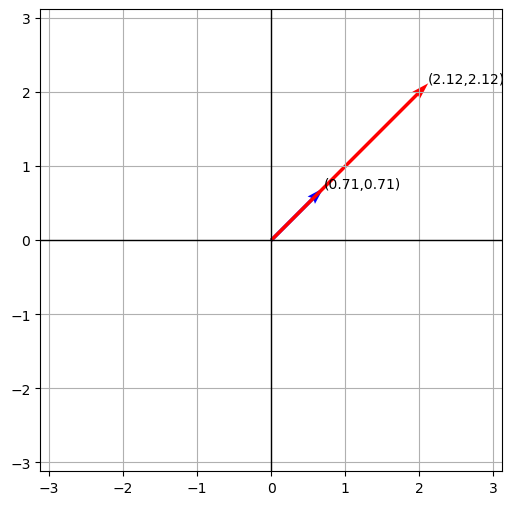

In [11]:
# v é um autovetor de A (primeira coluna de autovetores)
v = autovetores[:,0]
Av = A2@v

print('v  =', v)
print('Av =', Av, ' (paralelo a v, escala =', autovalores[0], ')')

plota_vetores_2d([v, Av], ['b', 'r'])

u  = [1 0]
Au = [2 1]  (direção diferente de u)


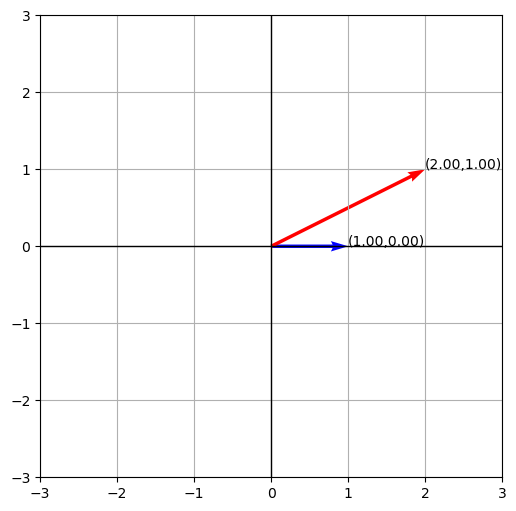

In [12]:
# u é um vetor qualquer, que não é autovetor de A
u = np.array([1, 0])
Au = A2@u

print('u  =', u)
print('Au =', Au, ' (direção diferente de u)')

plota_vetores_2d([u, Au], ['b', 'r'])

No primeiro gráfico, o vetor azul ($v$) e o vetor vermelho ($Av$) estão sobre a mesma reta: $A$ apenas *esticou* o autovetor $v$. Já no segundo gráfico, o vetor $u$ (azul) não é autovetor de $A$, e $Au$ (vermelho) aponta para uma direção diferente.

Como $A$ é simétrica, um resultado importante da Álgebra Linear garante que seus autovalores são sempre **reais** e que os autovetores associados a autovalores distintos são **ortogonais** entre si. Vamos verificar essa segunda propriedade calculando o produto escalar entre as duas colunas de `autovetores`.

In [13]:
v1 = autovetores[:,0]
v2 = autovetores[:,1]

np.dot(v1, v2)

O produto escalar é (numericamente) igual a zero, confirmando que $v_1 \perp v_2$.

## Diagonalização de matrizes

Suponha que uma matriz $A_{n\times n}$ possua $n$ autovetores linearmente independentes $v_1, v_2, \ldots, v_n$, associados aos autovalores $\lambda_1,\lambda_2,\ldots,\lambda_n$ (não necessariamente distintos). Formando a matriz $P$ cujas colunas são esses autovetores,

$$ P = \begin{bmatrix} v_1 & v_2 & \cdots & v_n \end{bmatrix} $$

e a matriz diagonal $D=\text{diag}(\lambda_1,\ldots,\lambda_n)$, pode-se mostrar que

$$ AP = PD \quad \Longrightarrow \quad A = PDP^{-1} $$

Quando isso é possível, dizemos que $A$ é **diagonalizável**. Uma condição suficiente (mas não necessária) para que $A$ seja diagonalizável é que todos os seus autovalores sejam distintos. De modo mais geral, $A$ é diagonalizável se, e somente se, para cada autovalor a multiplicidade geométrica for igual à multiplicidade algébrica.

A diagonalização é muito útil, por exemplo, para calcular potências de matrizes de forma eficiente, já que $A^k = PD^kP^{-1}$ e $D^k$ é obtida elevando cada elemento da diagonal de $D$ à potência $k$.

**Exemplo 3:** Vamos diagonalizar a matriz $A$ do Exemplo 1, usando o método `diagonalize` do `sympy`, que retorna diretamente as matrizes $P$ e $D$.

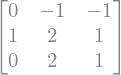

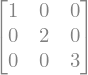

In [14]:
P, D = A.diagonalize()
display(P)
display(D)

Vamos conferir que, de fato, $A = PDP^{-1}$.

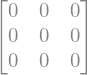

In [15]:
sp.simplify(P*D*P.inv() - A)

A matriz nula confirma que a decomposição está correta.

## Autovalores e autovetores com `numpy`

Para matrizes numéricas (sem incógnitas), em geral não usamos o `sympy`, que pode ficar lento para matrizes maiores, mas sim `numpy.linalg.eig`, que calcula autovalores e autovetores numericamente de forma muito mais eficiente.

**Exemplo 4:** Vamos recalcular, agora numericamente, os autovalores e autovetores da matriz do Exemplo 1 e comparar com o resultado obtido simbolicamente.

In [16]:
A_num = np.array([[4,0,1],[-2,1,0],[-2,0,1]], dtype=float)

autovalores, autovetores = np.linalg.eig(A_num)

print('Autovalores:', autovalores)
print('Autovetores (em colunas):')
print(autovetores)

Autovalores: [1. 3. 2.]
Autovetores (em colunas):
[[ 0.          0.57735027 -0.33333333]
 [ 1.         -0.57735027  0.66666667]
 [ 0.         -0.57735027  0.66666667]]


Os autovalores coincidem com os obtidos simbolicamente no Exemplo 1. Os autovetores calculados pelo `numpy` são normalizados (módulo igual a 1), por isso podem parecer diferentes dos obtidos com o `sympy`, mas representam as mesmas direções — basta verificar que um é múltiplo escalar do outro.

### Atividades:

**1.** Determine, manualmente (à mão) e depois conferindo com `sympy` ou `numpy`, os autovalores e autovetores da matriz

$$
A = \begin{bmatrix}
2 & 0 \\
0 & 3
\end{bmatrix}
$$

O que você pode observar sobre os autovalores de uma matriz diagonal?

In [17]:
# Cole e/ou escreva seu código aqui

**2.** Calcule os autovalores e autovetores da matriz

$$
B = \begin{bmatrix}
2 & 1 \\
0 & 2
\end{bmatrix}
$$

Quantos autovalores distintos ela possui? Qual é a multiplicidade algébrica desse autovalor? Encontre a multiplicidade geométrica e verifique se $B$ é diagonalizável.

In [18]:
# Cole e/ou escreva seu código aqui

**3.** Considere a matriz de rotação (vista em [I.3](I.3_matrizes_especiais_e_determinantes.ipynb))

$$R_\theta=\begin{bmatrix}\cos \theta & -\text{sen}\, \theta \\ \text{sen}\, \theta & \cos \theta\end{bmatrix}$$

com $\theta = \pi/2$. Calcule seus autovalores usando `sympy`. Eles são reais? Faz sentido, geometricamente, que uma rotação de $90°$ (diferente de $0°$ ou $180°$) tenha autovetores reais? Justifique sua resposta.

In [19]:
# Cole e/ou escreva seu código aqui

**4.** Crie uma matriz simétrica $3\times 3$ qualquer $S$ (lembre que $S=S^T$) e:

a) calcule seus autovalores e autovetores com `numpy`;

b) verifique que todos os autovalores são reais;

c) verifique que os autovetores são ortogonais dois a dois (produto escalar nulo).

In [20]:
# Cole e/ou escreva seu código aqui

**5.** Usando a matriz $A$ do Exemplo 2, escolha três vetores $u$ quaisquer que **não** sejam autovetores de $A$ e, para cada um, plote $u$ e $Au$ com a função `plota_vetores_2d`. Em seguida, escolha um vetor $w$ que seja um múltiplo escalar de um dos autovetores de $A$ (por exemplo, $w=3v_1$) e mostre que $Aw$ continua paralelo a $w$.

In [21]:
# Cole e/ou escreva seu código aqui

**6.** Uma matriz de iteração $H$ de um método iterativo (veja [I.6](I.6_metodos_iterativos_para_sistemas_lineares.ipynb)) converge se, e somente se, todos os seus autovalores satisfazem $|\lambda_i|<1$. Considere

$$
H = \begin{bmatrix}
0 & 0.5 & 0.2\\
0.4 & 0 & 0.3\\
0.1 & 0.2 & 0
\end{bmatrix}
$$

Calcule os autovalores de $H$ com `numpy` e verifique se o processo iterativo $x^{(k+1)}=Hx^{(k)}+g$ converge, qualquer que seja $g$.

In [22]:
# Cole e/ou escreva seu código aqui

### Referências

ANTON, Howard; RORRES, Chris. Álgebra Linear com Aplicações. 10. ed. Porto Alegre: Bookman, 2012.

ARENALES, Selma; DAREZZO, Artur. Cálculo Numérico: aprendizagem com Apoio de Software. 2. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2016.

BURDEN, Richard L.; FAIRES, J D.; BURDEN, Annette M. Análise Numérica - Tradução da 10ª edição norte-americana. 3. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2016.

CHAPRA, Steven C.; CANALE, Raymond P. Métodos numéricos para engenharia. 7. ed. Porto Alegre: AMGH, 2016.

RUGGIERO, M. A. G. e LOPES, V. L. R. Cálculo Numérico: Aspectos Teóricos e Computacionais. 2ª edição. Saraiva, 2016.
